In [1]:
##### Creates figures of scaling factors for sub-national and national scale

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
from sklearn.metrics import r2_score
import matplotlib.patches as mpatches

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import sub-national data
subnational_capital = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/subnational_scaling_factors_capital.csv")
subnational_labor = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/subnational_scaling_factors_labor.csv")

sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# Import country data
national_capital = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_capital.csv")
national_labor = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_labor.csv")

country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/scaling_factors"

In [3]:
### Data prep

# clear missing data (subnational capital has a lot because proxy countries witheld)
subnational_capital = subnational_capital.dropna()
subnational_labor = subnational_labor.dropna()
national_capital = national_capital.dropna()
national_labor = national_labor.dropna()

# calculate % difference for scaling factors 
subnational_capital['percent_diff'] = (subnational_capital['capital_USD'] - subnational_capital['sub_national_total_capital_USD']) / subnational_capital['sub_national_total_capital_USD']
subnational_capital['percent_diff_p10'] = (subnational_capital['capital_USD_p10'] - subnational_capital['sub_national_total_capital_USD']) / subnational_capital['sub_national_total_capital_USD']
subnational_capital['percent_diff_p90'] = (subnational_capital['capital_USD_p90'] - subnational_capital['sub_national_total_capital_USD']) / subnational_capital['sub_national_total_capital_USD']
subnational_capital = subnational_capital[np.isfinite(subnational_capital['percent_diff'])]

subnational_labor['percent_diff'] = (subnational_labor['jobs'] - subnational_labor['sub_national_total_jobs']) / subnational_labor['sub_national_total_jobs']
subnational_labor['percent_diff_p10'] = (subnational_labor['jobs_p10'] - subnational_labor['sub_national_total_jobs']) / subnational_labor['sub_national_total_jobs']
subnational_labor['percent_diff_p90'] = (subnational_labor['jobs_p90'] - subnational_labor['sub_national_total_jobs']) / subnational_labor['sub_national_total_jobs']
subnational_labor = subnational_labor[np.isfinite(subnational_labor['percent_diff'])]

national_capital['percent_diff'] = (national_capital['sub_scaled_capital_USD'] - national_capital['national_total_capital_USD']) / national_capital['national_total_capital_USD']
national_capital['percent_diff_p10'] = (national_capital['sub_scaled_capital_USD_p10'] - national_capital['national_total_capital_USD']) / national_capital['national_total_capital_USD']
national_capital['percent_diff_p90'] = (national_capital['sub_scaled_capital_USD_p90'] - national_capital['national_total_capital_USD']) / national_capital['national_total_capital_USD']
national_capital = national_capital[np.isfinite(national_capital['percent_diff'])]

national_labor['percent_diff'] = (national_labor['sub_scaled_jobs'] - national_labor['national_total_jobs']) / national_labor['national_total_jobs']
national_labor['percent_diff_p10'] = (national_labor['sub_scaled_jobs_p10'] - national_labor['national_total_jobs']) / national_labor['national_total_jobs']
national_labor['percent_diff_p90'] = (national_labor['sub_scaled_jobs_p90'] - national_labor['national_total_jobs']) / national_labor['national_total_jobs']
national_labor = national_labor[np.isfinite(national_labor['percent_diff'])]

#### R2 and coverage metrics

In [4]:
#### Compute R2 and coverage metrics for sub-national scaling factors

subnational_capital_r2 = r2_score(subnational_capital['sub_national_total_capital_USD'], subnational_capital['capital_USD'])
print(f"Subnational capital: {subnational_capital_r2:.4f}")

subnational_labor_r2 = r2_score(subnational_labor['sub_national_total_jobs'], subnational_labor['jobs'])
print(f"Subnational labor: {subnational_labor_r2:.4f}")

# Coverage: % of actual datapoints falling within the predicted p10-p90 range
capital_within_range = (
    (subnational_capital['sub_national_total_capital_USD'] >= subnational_capital['capital_USD_p10']) &
    (subnational_capital['sub_national_total_capital_USD'] <= subnational_capital['capital_USD_p90'])
)
capital_coverage = capital_within_range.mean() * 100
print(f"Subnational capital: {capital_coverage:.1f}% of datapoints within p10-p90 range")

labor_within_range = (
    (subnational_labor['sub_national_total_jobs'] >= subnational_labor['jobs_p10']) &
    (subnational_labor['sub_national_total_jobs'] <= subnational_labor['jobs_p90'])
)
labor_coverage = labor_within_range.mean() * 100
print(f"Subnational labor: {labor_coverage:.1f}% of datapoints within p10-p90 range")

Subnational capital: 0.8601
Subnational labor: 0.3880
Subnational capital: 88.4% of datapoints within p10-p90 range
Subnational labor: 80.7% of datapoints within p10-p90 range


In [5]:
#### Compute R2 and coverage metrics for national scaling factors

### First, exclude countries where sub-national scaling factors were used 
subnational_capital['ISO3'] = subnational_capital['PROJ_ID'].str[:3]
subnational_labor['ISO3'] = subnational_labor['PROJ_ID'].str[:3]

subnational_capital_countries = subnational_capital['ISO3'].unique().tolist()
subnational_labor_countries = subnational_labor['ISO3'].unique().tolist()

### Filter country data to exclude sub-national scaled countries 
national_capital_raw_only = national_capital[~national_capital['ISO3'].isin(subnational_capital_countries)]
national_labor_raw_only = national_labor[~national_labor['ISO3'].isin(subnational_labor_countries)]


#### Compute metrics
national_capital_r2 = r2_score(national_capital_raw_only['national_total_capital_USD'], national_capital_raw_only['sub_scaled_capital_USD'])
print(f"National capital: {national_capital_r2:.4f}")

national_labor_r2 = r2_score(national_labor_raw_only['national_total_jobs'], national_labor_raw_only['sub_scaled_jobs'])
print(f"National labor: {national_labor_r2:.4f}")

# Coverage: % of actual datapoints falling within the predicted p10-p90 range
capital_within_range = (
    (national_capital_raw_only['national_total_capital_USD'] >= national_capital_raw_only['sub_scaled_capital_USD_p10']) &
    (national_capital_raw_only['national_total_capital_USD'] <= national_capital_raw_only['sub_scaled_capital_USD_p90'])
)
capital_coverage = capital_within_range.mean() * 100
print(f"National capital: {capital_coverage:.1f}% of datapoints within p10-p90 range")

labor_within_range = (
    (national_labor_raw_only['national_total_jobs'] >= national_labor_raw_only['sub_scaled_jobs_p10']) &
    (national_labor_raw_only['national_total_jobs'] <= national_labor_raw_only['sub_scaled_jobs_p90'])
)
labor_coverage = labor_within_range.mean() * 100
print(f"National labor: {labor_coverage:.1f}% of datapoints within p10-p90 range")

National capital: 0.9636
National labor: 0.8398
National capital: 98.0% of datapoints within p10-p90 range
National labor: 99.3% of datapoints within p10-p90 range


#### Histograms of scaling factors

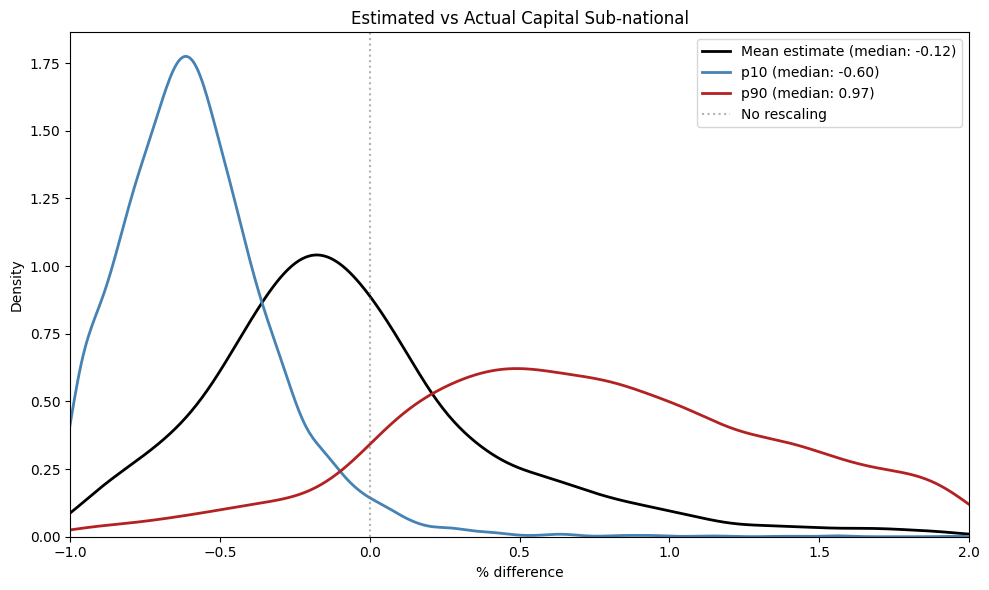

In [6]:
#### Histogram of subnational capital scaling factors 

vmin, vmax = -1, 2

fig, ax = plt.subplots(figsize=(10, 6))

cols = {
    'percent_diff': 'Mean estimate',
    'percent_diff_p10': 'p10',
    'percent_diff_p90': 'p90'
}
colors = {'percent_diff': 'black', 'percent_diff_p10': 'steelblue', 'percent_diff_p90': 'firebrick'}

for col, label in cols.items():
    data = subnational_capital[col].dropna()
    median_val = data.median()  # median of full data, for reference
    
    # Restrict to bounds BEFORE fitting KDE, so density is computed only within range
    data_in_range = data[(data >= vmin) & (data <= vmax)]
    
    data_in_range.plot.kde(ax=ax, label=f'{label} (median: {median_val:.2f})', 
                            color=colors[col], linewidth=2)

ax.axvline(0, color='grey', linestyle=':', alpha=0.6, label='No rescaling')
ax.set_xlim(vmin, vmax)
ax.set_ylim(bottom=0)
ax.set_xlabel('% difference')
ax.set_ylabel('Density')
ax.set_title('Estimated vs Actual Capital Sub-national')
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/subnational_capital_histogram.png", dpi=300, bbox_inches='tight')

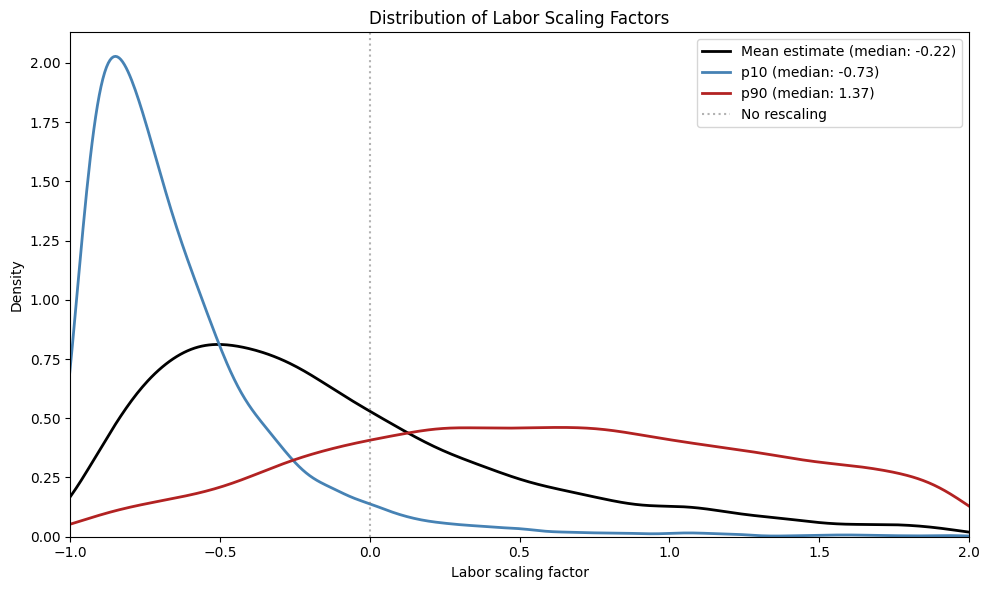

In [7]:
#### Histogram of subnational labor scaling factors 

vmin, vmax = -1, 2

fig, ax = plt.subplots(figsize=(10, 6))

cols = {
    'percent_diff': 'Mean estimate',
    'percent_diff_p10': 'p10',
    'percent_diff_p90': 'p90'
}
colors = {'percent_diff': 'black', 'percent_diff_p10': 'steelblue', 'percent_diff_p90': 'firebrick'}

for col, label in cols.items():
    data = subnational_labor[col].dropna()
    median_val = data.median()  # median of full data, for reference
    
    # Restrict to bounds BEFORE fitting KDE, so density is computed only within range
    data_in_range = data[(data >= vmin) & (data <= vmax)]
    
    data_in_range.plot.kde(ax=ax, label=f'{label} (median: {median_val:.2f})', 
                            color=colors[col], linewidth=2)

ax.axvline(0, color='grey', linestyle=':', alpha=0.6, label='No rescaling')
ax.set_xlim(vmin, vmax)
ax.set_ylim(bottom=0)
ax.set_xlabel('Labor scaling factor')
ax.set_ylabel('Density')
ax.set_title('Distribution of Labor Scaling Factors')
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/subnational_labor_histogram.png", dpi=300, bbox_inches='tight')

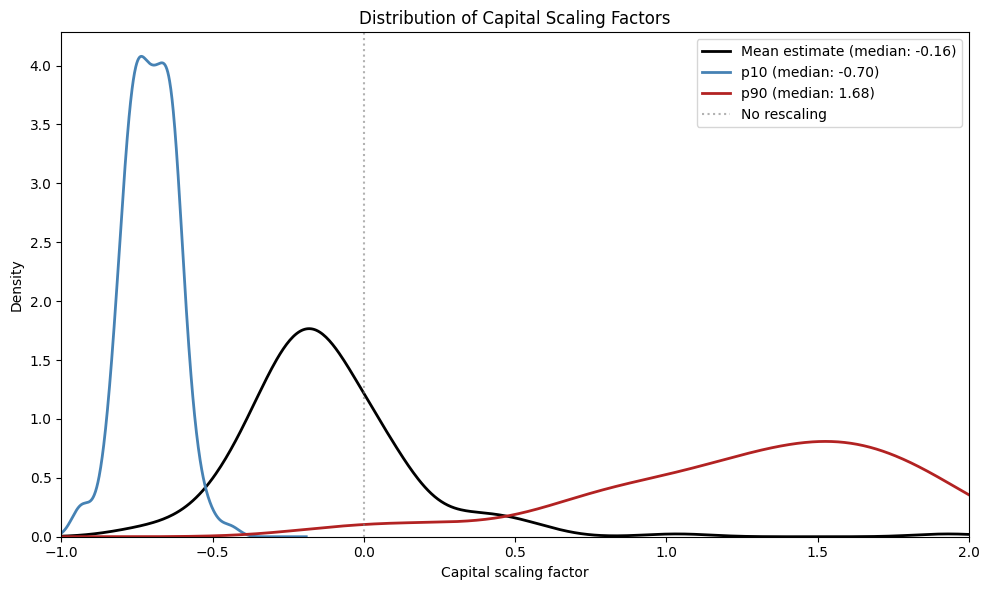

In [8]:
#### Histogram of national capital scaling factors (excluding countries where sub-national scaling was done)

vmin, vmax = -1, 2

fig, ax = plt.subplots(figsize=(10, 6))

cols = {
    'percent_diff': 'Mean estimate',
    'percent_diff_p10': 'p10',
    'percent_diff_p90': 'p90'
}
colors = {'percent_diff': 'black', 'percent_diff_p10': 'steelblue', 'percent_diff_p90': 'firebrick'}

for col, label in cols.items():
    data = national_capital_raw_only[col].dropna()
    median_val = data.median()  # median of full data, for reference
    
    # Restrict to bounds BEFORE fitting KDE, so density is computed only within range
    data_in_range = data[(data >= vmin) & (data <= vmax)]
    
    data_in_range.plot.kde(ax=ax, label=f'{label} (median: {median_val:.2f})', 
                            color=colors[col], linewidth=2)

ax.axvline(0, color='grey', linestyle=':', alpha=0.6, label='No rescaling')
ax.set_xlim(vmin, vmax)
ax.set_ylim(bottom=0)
ax.set_xlabel('Capital scaling factor')
ax.set_ylabel('Density')
ax.set_title('Distribution of Capital Scaling Factors')
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/national_capital_histogram.png", dpi=300, bbox_inches='tight')

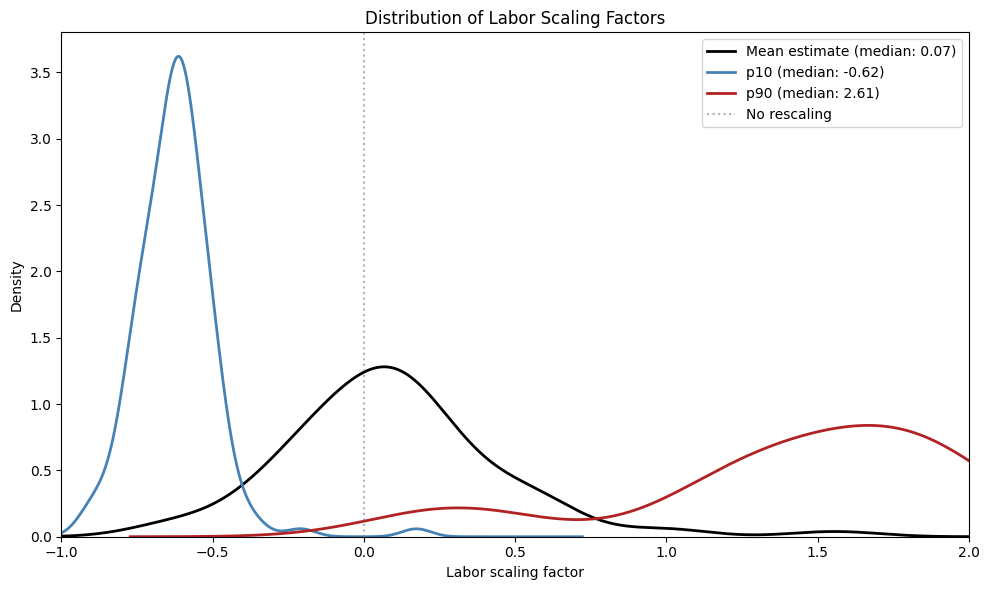

In [9]:
#### Histogram of national labor scaling factors (excluding countries where sub-national scaling was done)

vmin, vmax = -1, 2

fig, ax = plt.subplots(figsize=(10, 6))

cols = {
    'percent_diff': 'Mean estimate',
    'percent_diff_p10': 'p10',
    'percent_diff_p90': 'p90'
}
colors = {'percent_diff': 'black', 'percent_diff_p10': 'steelblue', 'percent_diff_p90': 'firebrick'}

for col, label in cols.items():
    data = national_labor_raw_only[col].dropna()
    median_val = data.median()  # median of full data, for reference
    
    # Restrict to bounds BEFORE fitting KDE, so density is computed only within range
    data_in_range = data[(data >= vmin) & (data <= vmax)]
    
    data_in_range.plot.kde(ax=ax, label=f'{label} (median: {median_val:.2f})', 
                            color=colors[col], linewidth=2)

ax.axvline(0, color='grey', linestyle=':', alpha=0.6, label='No rescaling')
ax.set_xlim(vmin, vmax)
ax.set_ylim(bottom=0)
ax.set_xlabel('Labor scaling factor')
ax.set_ylabel('Density')
ax.set_title('Distribution of Labor Scaling Factors')
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/national_labor_histogram.png", dpi=300, bbox_inches='tight')

#### Map scaling factors

In [10]:
### Data prep

# align crs
crs = "ESRI:54042"

sub_geo_capital = sub_geo_capital.to_crs(crs)
sub_geo_labor = sub_geo_labor.to_crs(crs)
country_shp = country_shp.to_crs(crs)

# prep country shp 
country_shp = country_shp.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='inner')

# join data to shape
sub_geo_capital = sub_geo_capital.merge(subnational_capital, on='PROJ_ID', how='inner')
sub_geo_labor = sub_geo_labor.merge(subnational_labor, on='PROJ_ID', how='inner')

country_shp_all_cap = country_shp.merge(national_capital, on='ISO3', how='outer')
country_shp_all_lab = country_shp.merge(national_labor, on='ISO3', how='outer')

country_shp_raw_only_cap = country_shp.merge(national_capital_raw_only, on='ISO3', how='outer')
country_shp_raw_only_lab = country_shp.merge(national_labor_raw_only, on='ISO3', how='outer')

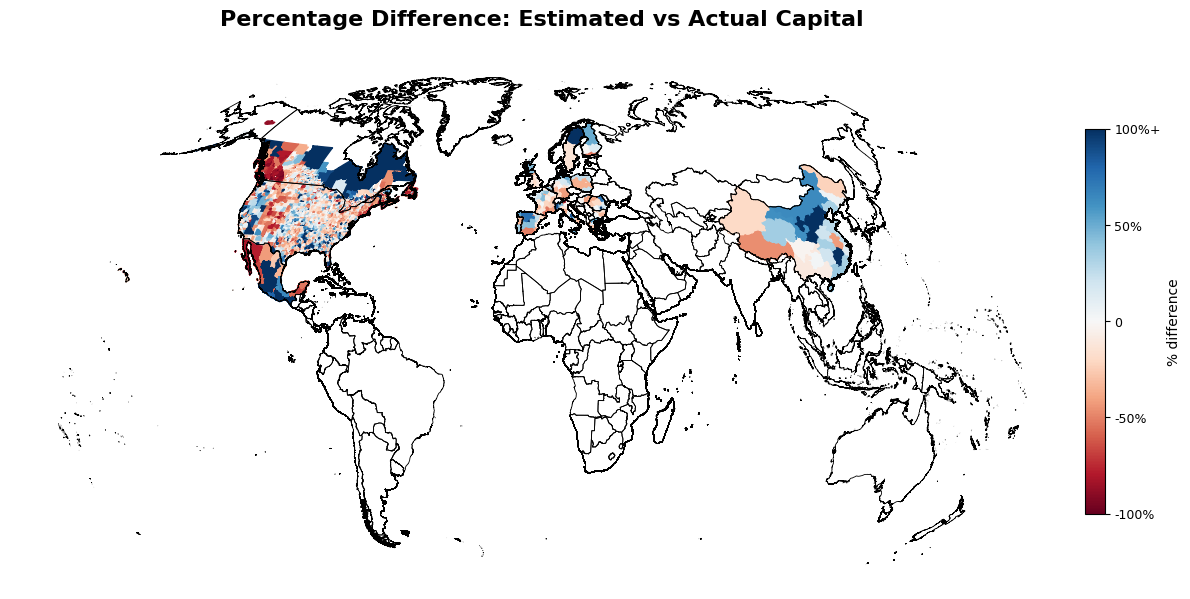

In [26]:
##### Plot sub-national scaling factors (capital)

bounds = [-1, -0.5, 0, 0.5, 1] 
labels = ['-100%', '-50%', '0', '50%', '100%+']

### Plot
fig, ax = plt.subplots(figsize=(12,8))
vmin, vmax = -1, 1

# Plot continuous values
sub_geo_capital.plot(
    column='percent_diff',
    cmap='RdBu',
    edgecolor='face',
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    legend=False,  
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Colorbar 
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Percentage Difference: Estimated vs Actual Capital", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_capital_map.png", dpi=300, bbox_inches='tight')

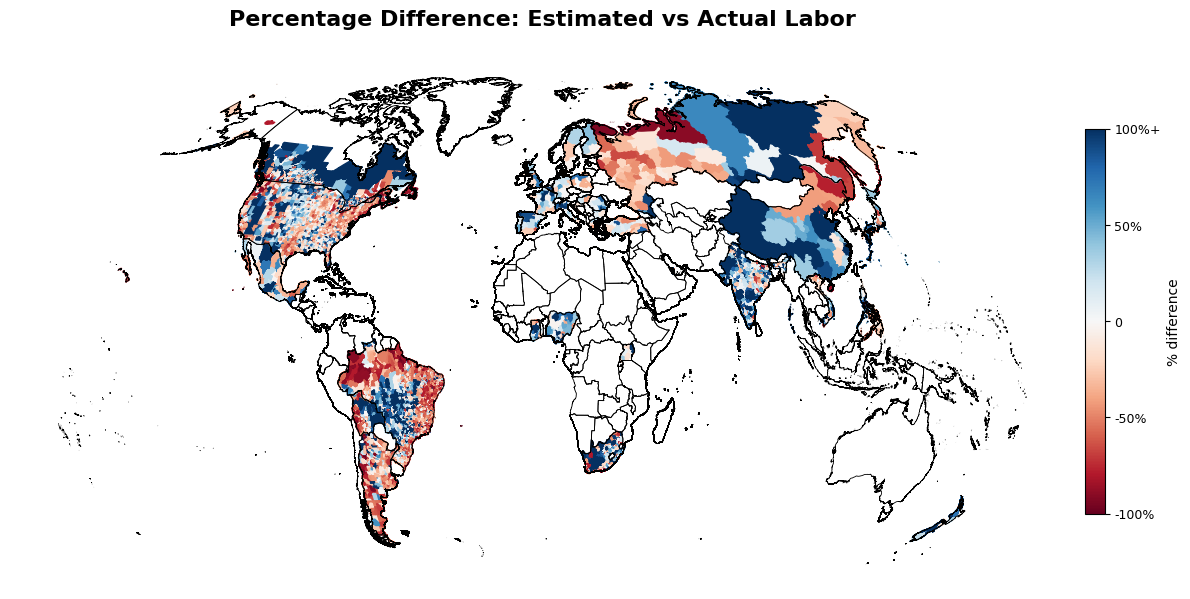

In [27]:
##### Plot sub-national scaling factors (labor)

bounds = [-1, -0.5, 0, 0.5, 1] 
labels = ['-100%', '-50%', '0', '50%', '100%+']

### Plot
fig, ax = plt.subplots(figsize=(12,8))
vmin, vmax = -1, 1

# Plot continuous values
sub_geo_labor.plot(
    column='percent_diff',
    cmap='RdBu',
    edgecolor='face',
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    legend=False,  
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Colorbar 
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Percentage Difference: Estimated vs Actual Labor", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_labor_map.png", dpi=300, bbox_inches='tight')

In [ ]:
##### Plot national scaling factors (capital)

bounds = [-1, -0.5, 0, 0.5, 1] 
labels = ['-100%', '-50%', '0', '50%', '100%+']

### Plot
fig, ax = plt.subplots(figsize=(12,8))
vmin, vmax = -1, 1

# Plot raw values
country_shp_raw_only_cap.plot(
    column='percent_diff',
    cmap='RdBu',
    edgecolor='face',
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    legend=False,  
    zorder=2
)

# Plot values which were rescaled sub-nationally
country_shp_all_cap.plot(
    column='percent_diff',
    cmap='RdBu',
    edgecolor='black',
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    legend=False,  
    hatch='.',
    zorder=1
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Colorbar 
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Percentage Difference: Estimated vs Actual Capital", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/national_capital_map.png", dpi=300, bbox_inches='tight')